# Falcon Noise Analysis

The noise in the Falcon-style (dual-complement, single-disc) airborne gravity gradiometer is well characterised by the difference noise. Thus the noise in each component is half the standard deviation of the difference between complements):

$$N_{NE}=0.5\,\sigma\left(A_{NE}-B_{NE}\right)$$
$$N_{UV}=0.5\,\sigma\left(A_{UV}-B_{UV}\right)$$

where $A_{NE}$ is the $NE$ component of the gravity gradient as measured by the $A$ complement, and similarly for $A_{UV}$, $B_{NE}$, and $B_{UV}$. It is also useful to check for excess high frequency signal, and to check for any demodulation phase error as described below.

We will use the Canobie Falcon data for these examples so ensure you have run the `Prepare_XYZ` notebook first so that these data are prepared for review.

___

Import the required modules, set the path to the geowhizz files and list the channels.

In [1]:
from pathlib import Path
import galileoQC as qc

In [2]:
data_root = r'./CanobieData/'
canobieHDF_file = Path(data_root + r'Canobie.hdf5')

In [3]:
qc.reportChannels(canobieHDF_file)

Whizz Version 1.0

33 channels:


33 channels:
['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67',
'Bearing', 'CLEARANCE', 'DTM', 'Date', 'EASTING', 'FIDUCIAL',
'FLIGHT', 'GDD_Fourier_2p67', 'GNE_Fourier_2p67', 'GUV_Fourier_2p67',
'HDOP', 'HEIGHT', 'JOB_ID', 'LATITUDE', 'LINE', 'LONGITUDE',
'NORTHING', 'Noise_NE', 'Noise_UV', 'NumSats', 'PDOP', 'TURBULENCE',
'T_DD', 'T_NE', 'T_UV', 'Time_1980', 'Time_Day', 'VDOP',
'gD_Fourier_2p67']


___

The **`diffNoiseVturb`** function plots the difference noise for each survey line against the turbulence for that line. Higher turbulence generally results in higher noise and the plot allows one to decide on a reasonable turbulence limit for the data. In addition, flight-lines with a difference noise that is off the general trend (high noise at low turbulence) should be questioned even if they meet specification.

In this example, we get very low noise estimates and there are no data off-trend.

The usual `error_spec` is $5\,E$ but here we have set it to $2.5\,E$ in order to force an error message, purely for an example. You can see that lines that fail the set specification are labeled on the plot.

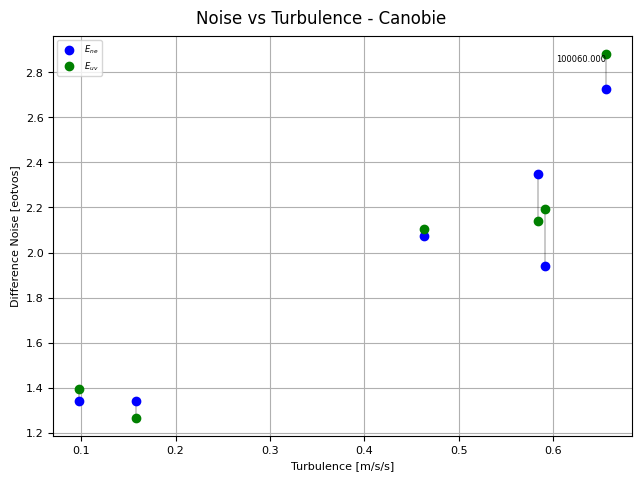

100060.000 fails with noise 2.80 > 2.5, mean turbulence = 0.66.



In [4]:
qc.diffNoiseVturb(canobieHDF_file, eNE='Noise_NE', eUV='Noise_UV', turbulence='TURBULENCE',
                  error_spec=2.5, labelLines=True)

___

Any rectification process can down-convert high frequency vibration into the signal band of a sensor. Gravity gradiometers have an intrinsic rectification process via their sensitivity to products of rotational velocity so it is useful to check for excess high frequency signal since it may lead to error in the final data.

The function **`checkHighFreq`** checks for unusually high amplitude, high frequency signal in the raw gradient channels. The input gradient channels are high-pass filtered and a rolling standard deviation is used to find periods of higher amplitudes. High turbulence is sometimes associated with high frequency noise so the turbulence is also plotted for comparison.

Experience with Falcon data suggests that sections of data where `checkHighFreq` finds high frequency noise above $15\,E$ are of concern and ought to be followed up with the service provider.

A plot showing where the high frequency noise occurs along line is shown for all lines that have excess high frequency signal. The Canobie data do not have any high frequency noise problems, so the `noiseLimit` has been artifically set here to $6.5\,E$ just to get a plot for the example.

Checked 6 lines; 1 line had high frequency signal above 6.5.
Line 100030.000: peak HF noise in ANE_TC_2p67 = 6.9.



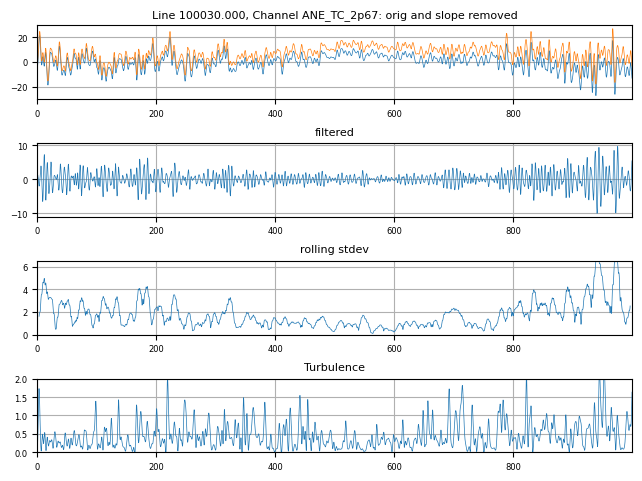

In [5]:
qc.checkHighFreq(canobieHDF_file, noiseLimit=6.5, 
                 channels=['ANE_TC_2p67', 'AUV_TC_2p67', 'BNE_TC_2p67', 'BUV_TC_2p67'], 
                 cutoffs=[0.15, 3.6], vertaccel='TURBULENCE', verbose=True, plot_flag=True)